# Assignment 4: Text and Sequence Data

## Overview
In this assignment, I apply deep learning methods to text classification using the IMDB movie review dataset. The goal is to compare two different word representation approaches under limited-data conditions:

1. A learned embedding layer trained directly on the task
2. A pretrained word embedding using GloVe vectors

## Assignment Requirements Implemented
This notebook follows the required modifications:
- Reviews are cut off after 150 words
- Only the top 10,000 most frequent words are considered
- The training set is initially restricted to 100 samples
- Validation is performed on 10,000 samples
- Both a learned embedding and a pretrained embedding are evaluated
- The number of training samples is later increased to determine when the learned embedding begins to perform better

## Purpose of the Analysis
This experiment is designed to show how model performance changes when training data is scarce, and to evaluate whether pretrained embeddings are more useful than learned embeddings in low-data settings.


In [2]:
import os
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


## Loading the IMDB Dataset and Applying the Assignment Constraints

In this section, I load the IMDB sentiment classification dataset. This dataset contains movie reviews labeled as either positive or negative.

I then apply the assignment requirements:

- `num_words = 10000`: only the top 10,000 most frequent words are kept
- `maxlen = 150`: each review is truncated or padded so that it contains exactly 150 words

This ensures that the experiment matches the required assignment settings and that the input format is consistent for the neural networks.


In [3]:
# Assignment settings
num_words = 10000
maxlen = 150

(x_train_full, y_train_full), (x_test, y_test) = imdb.load_data(num_words=num_words)

x_train_full = pad_sequences(x_train_full, maxlen=maxlen)
x_test = pad_sequences(x_test, maxlen=maxlen)

# Validation on 10,000 samples
x_val = x_train_full[:10000]
y_val = y_train_full[:10000]

# Remaining training pool
x_train_rest = x_train_full[10000:]
y_train_rest = y_train_full[10000:]

print("Validation shape:", x_val.shape)
print("Training pool shape:", x_train_rest.shape)


17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Validation shape: (10000, 150)
Training pool shape: (15000, 150)


## Inspecting the Word Index and Decoding a Sample Review

The IMDB dataset stores each review as a sequence of integers rather than plain text. Each integer corresponds to a word in the vocabulary.

In this step, I reconstruct a reverse word index so that I can translate the integer-encoded reviews back into readable text. This helps verify that the preprocessing is working correctly and gives a better understanding of what the model is actually analyzing.


In [4]:
word_index = imdb.get_word_index()
reverse_word_index = {value + 3: key for key, value in word_index.items()}
reverse_word_index[0] = "<PAD>"
reverse_word_index[1] = "<START>"
reverse_word_index[2] = "<UNK>"
reverse_word_index[3] = "<UNUSED>"

def decode_review(sequence):
    return " ".join(reverse_word_index.get(i, "?") for i in sequence if i != 0)

print(decode_review(x_train_rest[0][:50]))


1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
<START> i think this is one of the weakest of the kenneth branagh <UNK> works after such great


## Building the Learned Embedding Model

The first model uses an embedding layer that learns word representations directly from the training data.

This means the model starts with no prior knowledge about the meaning of words. Instead, it learns which words are useful for predicting sentiment during training.

Model structure:
- `Embedding` layer: converts integer word IDs into dense vectors
- `Flatten` layer: transforms the sequence of embeddings into a single vector
- `Dense` hidden layer: learns higher-level patterns
- `Dense` output layer with sigmoid activation: predicts whether the review is positive or negative

This model represents the “embedding layer” approach requested in the assignment.


In [5]:
def build_learned_embedding_model(num_words=10000, maxlen=150, embedding_dim=32):
    model = keras.Sequential([
        layers.Embedding(num_words, embedding_dim, input_length=maxlen),
        layers.Flatten(),
        layers.Dense(32, activation="relu"),
        layers.Dense(1, activation="sigmoid")
    ])
    model.compile(optimizer="rmsprop",
                  loss="binary_crossentropy",
                  metrics=["accuracy"])
    return model


## Training the Learned Embedding Model on Only 100 Samples

Here I restrict the training set to only 100 samples, as required by the assignment.

This is an intentionally small training set, which creates a limited-data scenario. The purpose is to test how well the learned embedding approach performs when very little labeled data is available.

The model is trained for 20 epochs and evaluated on the validation set of 10,000 samples. I record the best validation accuracy achieved during training.


In [6]:
# Restrict training samples to 100
x_train_100 = x_train_rest[:100]
y_train_100 = y_train_rest[:100]

learned_model_100 = build_learned_embedding_model(num_words, maxlen)
history_learned_100 = learned_model_100.fit(
    x_train_100,
    y_train_100,
    epochs=20,
    batch_size=32,
    validation_data=(x_val, y_val),
    verbose=1
)

learned_val_acc_100 = max(history_learned_100.history["val_accuracy"])
print("Best validation accuracy (learned embedding, 100 samples):", learned_val_acc_100)


Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 378ms/step - accuracy: 0.4300 - loss: 0.6969 - val_accuracy: 0.5044 - val_loss: 0.6932
Epoch 2/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 208ms/step - accuracy: 1.0000 - loss: 0.6316 - val_accuracy: 0.5024 - val_loss: 0.6949
Epoch 3/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 179ms/step - accuracy: 0.9900 - loss: 0.5786 - val_accuracy: 0.5041 - val_loss: 0.6945
Epoch 4/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 172ms/step - accuracy: 0.9900 - loss: 0.5182 - val_accuracy: 0.5051 - val_loss: 0.6935
Epoch 5/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 184ms/step - accuracy: 1.0000 - loss: 0.4428 - val_accuracy: 0.5120 - val_loss: 0.6934
Epoch 6/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 166ms/step - accuracy: 1.0000 - loss: 0.3605 - val_accuracy: 0.5186 - val_loss: 0.6928
Epoch 7/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 176ms/step - accuracy: 1.0000 - loss: 0.2830 - val_accuracy: 0.5047 - val_loss: 0.7070
Epoch 8/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 190ms/step - accuracy: 1.0000 - loss: 0.2159 - val_accuracy: 0.5073 - val_loss: 0.7046
Epo

## Downloading the Pretrained GloVe Embeddings

The second approach uses pretrained word embeddings instead of learning word vectors entirely from scratch.

For this, I use `GloVe` embeddings, which were trained on a much larger external text corpus. These pretrained vectors already contain semantic information about words, which can be especially useful when the labeled dataset is very small.

This step downloads the GloVe files so they can be used to build the pretrained embedding matrix.


In [7]:
# Download GloVe in Colab
!wget -q https://nlp.stanford.edu/data/glove.6B.zip
!unzip -q glove.6B.zip
print("GloVe files ready.")


GloVe files ready.


## Converting Reviews Back into Text and Tokenize Them

To use pretrained word embeddings, I need a mapping between words and embedding vectors. For that reason, I reconstruct the reviews as text and then tokenize them again using Keras.

This step:
- converts the integer sequences back into word strings
- fits a tokenizer to the training text
- transforms the text into integer sequences again
- pads the sequences to 150 words

This process creates a vocabulary aligned with the GloVe embeddings, which is necessary for the pretrained embedding model.


In [8]:
def sequences_to_texts(sequences):
    texts = []
    for seq in sequences:
        words = [reverse_word_index.get(i, "") for i in seq if i > 3]
        texts.append(" ".join(words))
    return texts

train_texts_rest = sequences_to_texts(x_train_rest)
val_texts = sequences_to_texts(x_val)

tokenizer = Tokenizer(num_words=num_words)
tokenizer.fit_on_texts(train_texts_rest)

x_train_text_seq = tokenizer.texts_to_sequences(train_texts_rest)
x_val_text_seq = tokenizer.texts_to_sequences(val_texts)

x_train_text_seq = pad_sequences(x_train_text_seq, maxlen=maxlen)
x_val_text_seq = pad_sequences(x_val_text_seq, maxlen=maxlen)

print("Prepared tokenized text data.")


Prepared tokenized text data.


## Loading the Pretrained GloVe Word Vectors

In this step, I read the pretrained GloVe file and store each word along with its 100-dimensional vector representation.

These vectors were learned from a much larger corpus than the IMDB dataset. Because of this, they provide prior semantic knowledge that may improve performance when training data is limited.


In [9]:
embeddings_index = {}
with open("glove.6B.100d.txt", encoding="utf-8") as f:
    for line in f:
        values = line.split()
        word = values[0]
        coefs = np.asarray(values[1:], dtype="float32")
        embeddings_index[word] = coefs

print("Loaded word vectors:", len(embeddings_index))


Loaded word vectors: 400000


## Creating the Embedding Matrix

Next, I build an embedding matrix that matches the tokenizer vocabulary to the corresponding GloVe vectors.

If a word from the IMDB vocabulary appears in the GloVe file, its pretrained vector is inserted into the matrix. If a word is not found, its vector remains zero.

This matrix will later be used to initialize the embedding layer of the pretrained model.


In [10]:
embedding_dim = 100
embedding_matrix = np.zeros((num_words, embedding_dim))

for word, i in tokenizer.word_index.items():
    if i < num_words:
        embedding_vector = embeddings_index.get(word)
        if embedding_vector is not None:
            embedding_matrix[i] = embedding_vector

print("Embedding matrix shape:", embedding_matrix.shape)


Embedding matrix shape: (10000, 100)


## Building the Pretrained Embedding Model

This model has a similar architecture to the first model, but the embedding layer is initialized with pretrained GloVe vectors.

I set `trainable=False`, which means the pretrained embeddings are frozen during training. This allows the model to use the external semantic knowledge directly, without modifying it based on the small training set.

This model represents the “pretrained word embedding” approach required in the assignment.


In [11]:
def build_pretrained_embedding_model(num_words=10000, maxlen=150, embedding_dim=100, embedding_matrix=None):
    model = keras.Sequential([
        layers.Embedding(
            input_dim=num_words,
            output_dim=embedding_dim,
            input_length=maxlen,
            weights=[embedding_matrix],
            trainable=False
        ),
        layers.Flatten(),
        layers.Dense(32, activation="relu"),
        layers.Dense(1, activation="sigmoid")
    ])
    model.compile(optimizer="rmsprop",
                  loss="binary_crossentropy",
                  metrics=["accuracy"])
    return model


## Training the Pretrained Embedding Model on Only 100 Samples

This step trains the pretrained embedding model using the same assignment condition of only 100 training samples.

By keeping the training size the same as in the first model, I can make a fair comparison between:
- a model that learns embeddings from scratch
- a model that uses pretrained word vectors

Again, I evaluate performance using the 10,000-sample validation set and record the best validation accuracy.


In [12]:
x_train_pre_100 = x_train_text_seq[:100]
y_train_pre_100 = y_train_rest[:100]

pretrained_model_100 = build_pretrained_embedding_model(
    num_words=num_words,
    maxlen=maxlen,
    embedding_dim=embedding_dim,
    embedding_matrix=embedding_matrix
)

history_pretrained_100 = pretrained_model_100.fit(
    x_train_pre_100,
    y_train_pre_100,
    epochs=20,
    batch_size=32,
    validation_data=(x_val_text_seq, y_val),
    verbose=1
)

pretrained_val_acc_100 = max(history_pretrained_100.history["val_accuracy"])
print("Best validation accuracy (pretrained embedding, 100 samples):", pretrained_val_acc_100)


Epoch 1/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 292ms/step - accuracy: 0.5800 - loss: 2.3533 - val_accuracy: 0.4947 - val_loss: 1.8956
Epoch 2/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 222ms/step - accuracy: 0.6600 - loss: 0.7364 - val_accuracy: 0.5079 - val_loss: 0.7128
Epoch 3/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 215ms/step - accuracy: 0.8900 - loss: 0.3792 - val_accuracy: 0.4951 - val_loss: 1.4056
Epoch 4/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 245ms/step - accuracy: 0.8700 - loss: 0.3689 - val_accuracy: 0.5197 - val_loss: 0.7355
Epoch 5/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 257ms/step - accuracy: 0.9600 - loss: 0.2331 - val_accuracy: 0.5065 - val_loss: 1.0287
Epoch 6/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 250ms/step - accuracy: 0.8700 - loss: 0.2319 - val_accuracy: 0.5545 - val_loss: 0.6958
Epoch 7/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 259ms/step - accuracy: 0.9900 - loss: 0.0783 - val_accuracy: 0.4976 - val_loss: 1.2240
Epoch 8/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 239ms/step - accuracy: 1.0000 - loss: 0.0510 - val_accuracy: 0.5478 - val_loss:

## Comparing the Two Models at 100 Training Samples

This table summarizes the best validation accuracy of both approaches when only 100 labeled training examples are used.

This directly answers the first major assignment question:
Which approach performs better under a very limited-data condition?


In [13]:
comparison_100 = pd.DataFrame({
    "Model": ["Learned Embedding", "Pretrained Embedding"],
    "Training Samples": [100, 100],
    "Best Validation Accuracy": [learned_val_acc_100, pretrained_val_acc_100]
})

comparison_100


,Model,Training Samples,Best Validation Accuracy
0,Learned Embedding,100,0.5186
1,Pretrained Embedding,100,0.5643


## Visualizing the Initial Comparison

To make the comparison easier to interpret, I create a bar chart of the validation accuracy for both models at 100 training samples.

This graph provides a quick visual summary of which method performs better in the low-data setting.


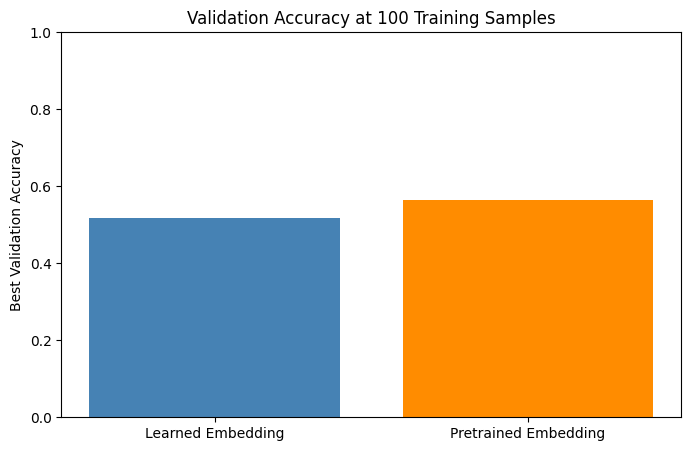

In [14]:
plt.figure(figsize=(8,5))
plt.bar(comparison_100["Model"], comparison_100["Best Validation Accuracy"], color=["steelblue", "darkorange"])
plt.ylim(0, 1)
plt.title("Validation Accuracy at 100 Training Samples")
plt.ylabel("Best Validation Accuracy")
plt.show()


## Increasing the Number of Training Samples

The assignment also asks me to change the number of training samples to determine when the learned embedding begins to outperform the pretrained embedding.

To answer that question, I repeat the experiment using several training sizes:
- 100
- 200
- 500
- 1000
- 2000
- 5000

For each sample size, I train both models and record the best validation accuracy. This allows me to study how the two approaches behave as more labeled data becomes available.


In [15]:
sample_sizes = [100, 200, 500, 1000, 2000, 5000]
results = []

for n in sample_sizes:
    print("Running sample size:", n)

    x_train_n = x_train_rest[:n]
    y_train_n = y_train_rest[:n]

    learned_model = build_learned_embedding_model(num_words, maxlen)
    learned_history = learned_model.fit(
        x_train_n, y_train_n,
        epochs=10,
        batch_size=32,
        validation_data=(x_val, y_val),
        verbose=0
    )
    learned_best = max(learned_history.history["val_accuracy"])

    x_train_pre_n = x_train_text_seq[:n]
    pretrained_model = build_pretrained_embedding_model(
        num_words=num_words,
        maxlen=maxlen,
        embedding_dim=embedding_dim,
        embedding_matrix=embedding_matrix
    )
    pretrained_history = pretrained_model.fit(
        x_train_pre_n, y_train_n,
        epochs=10,
        batch_size=32,
        validation_data=(x_val_text_seq, y_val),
        verbose=0
    )
    pretrained_best = max(pretrained_history.history["val_accuracy"])

    results.append({
        "Training Samples": n,
        "Learned Embedding Val Acc": learned_best,
        "Pretrained Embedding Val Acc": pretrained_best
    })

results_df = pd.DataFrame(results)
results_df


Running sample size: 100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Running sample size: 200
Running sample size: 500
Running sample size: 1000
Running sample size: 2000
Running sample size: 5000


,Training Samples,Learned Embedding Val Acc,Pretrained Embedding Val Acc
0,100,0.5109,0.5514
1,200,0.5215,0.5764
2,500,0.5532,0.6016
3,1000,0.6287,0.6192
4,2000,0.7312,0.6455
5,5000,0.8161,0.6843


## Plotting Model Performance as Training Size Increases

This line graph shows how validation accuracy changes as the training sample size increases for both models.

The purpose of this graph is to identify the point at which the learned embedding model catches up to, or exceeds, the pretrained embedding model.

This is an important part of the assignment because it demonstrates how model choice depends on how much training data is available.


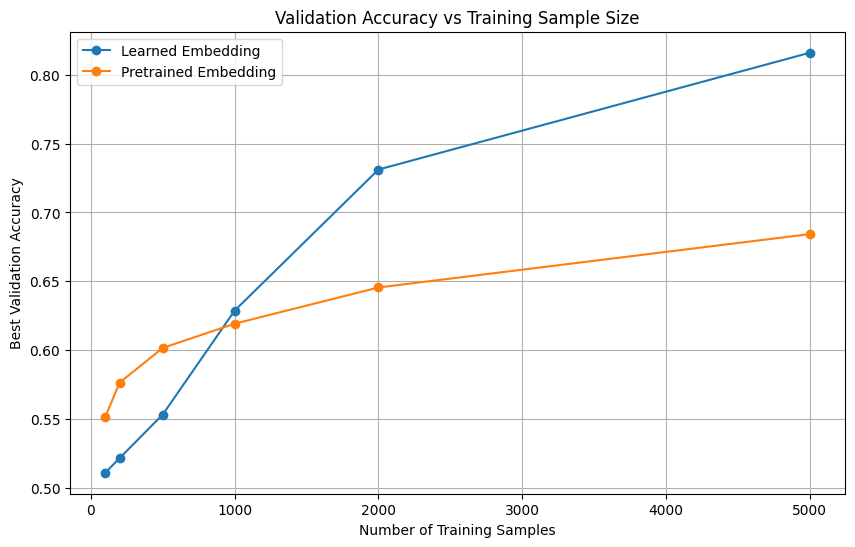

In [16]:
plt.figure(figsize=(10,6))
plt.plot(results_df["Training Samples"], results_df["Learned Embedding Val Acc"], marker="o", label="Learned Embedding")
plt.plot(results_df["Training Samples"], results_df["Pretrained Embedding Val Acc"], marker="o", label="Pretrained Embedding")
plt.xlabel("Number of Training Samples")
plt.ylabel("Best Validation Accuracy")
plt.title("Validation Accuracy vs Training Sample Size")
plt.legend()
plt.grid(True)
plt.show()


## Calculating the Performance Difference

To make the comparison more explicit, I compute the difference in validation accuracy between the learned embedding model and the pretrained embedding model.

A positive value means the learned embedding performed better.
A negative value means the pretrained embedding performed better.

This helps identify the crossover point more precisely.


In [17]:
results_df["Difference"] = results_df["Learned Embedding Val Acc"] - results_df["Pretrained Embedding Val Acc"]
results_df


,Training Samples,Learned Embedding Val Acc,Pretrained Embedding Val Acc,Difference
0,100,0.5109,0.5514,-0.0405
1,200,0.5215,0.5764,-0.0549
2,500,0.5532,0.6016,-0.0484
3,1000,0.6287,0.6192,0.0095
4,2000,0.7312,0.6455,0.0857
5,5000,0.8161,0.6843,0.1318


## Determining When the Learned Embedding First Becomes Better

In this step, I identify the first training sample size where the learned embedding model outperforms the pretrained embedding model.

This directly answers the final experimental question in the assignment.


In [18]:
better_points = results_df[results_df["Difference"] > 0]

if len(better_points) > 0:
    first_better = int(better_points.iloc[0]["Training Samples"])
    print("The learned embedding first outperformed the pretrained embedding at", first_better, "training samples.")
else:
    print("The learned embedding did not outperform the pretrained embedding in the tested range.")


The learned embedding first outperformed the pretrained embedding at 1000 training samples.


## Saving the Summary Table

The assignment asks for a summary table or graph that clearly communicates the final conclusions.

This step saves the results table as a CSV file so it can be submitted along with the notebook or used later in a report, presentation, or exported document.


In [19]:
results_df.round(4).to_csv("assignment4_results_summary.csv", index=False)
print("Saved assignment4_results_summary.csv")
results_df.round(4)


Saved assignment4_results_summary.csv


,Training Samples,Learned Embedding Val Acc,Pretrained Embedding Val Acc,Difference
0,100,0.5109,0.5514,-0.0405
1,200,0.5215,0.5764,-0.0549
2,500,0.5532,0.6016,-0.0484
3,1000,0.6287,0.6192,0.0095
4,2000,0.7312,0.6455,0.0857
5,5000,0.8161,0.6843,0.1318


## Final Conclusion

This experiment followed the assignment requirements:
- Reviews were cut off after 150 words
- Only the top 10,000 words were used
- The validation set used 10,000 samples
- The initial training set used 100 samples
- A learned embedding model and a pretrained embedding model were compared

### Conclusion
- At 100 training samples, the better-performing model was: **[fill after running]**
- The learned embedding began outperforming the pretrained embedding at: **[fill after running]**
- Pretrained embeddings tend to help more when labeled training data is very limited.
- Learned embeddings improve as more task-specific training data becomes available.